Customer Behavior Summary:
   user_id  total_orders  total_quantity  total_gmv segment
0  0000e88             2             7.0    9491.60  Medium
1  000159a            21           162.0   84908.69    High
2  000c1b2             1             3.0    5304.84     Low
3  0039abd             1             3.0    2098.24     Low
4  003b0e5             1             9.0    2525.84     Low
Sales Trends Summary:
  order_month    total_gmv  total_orders
0     2022-09  28588980.49          3526
1     2022-10  27677926.44          2682
2     2022-11  31826184.02          3538
3     2023-09  31717114.58          4148
4     2023-10  22833707.32          3124
Top Performing SKUs:
       sku_id   total_gmv  total_quantity  total_orders
1656  aa61eaa  3358729.54          2187.0          1098
1863  bd7c360  3033729.76          1525.0           817
880   5778589  2004186.77          1504.0           847
2     0072cca  1818349.65          1001.0           649
1363  8a9517a  1770669.35          1486.0   

C:\Users\srini\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\srini\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


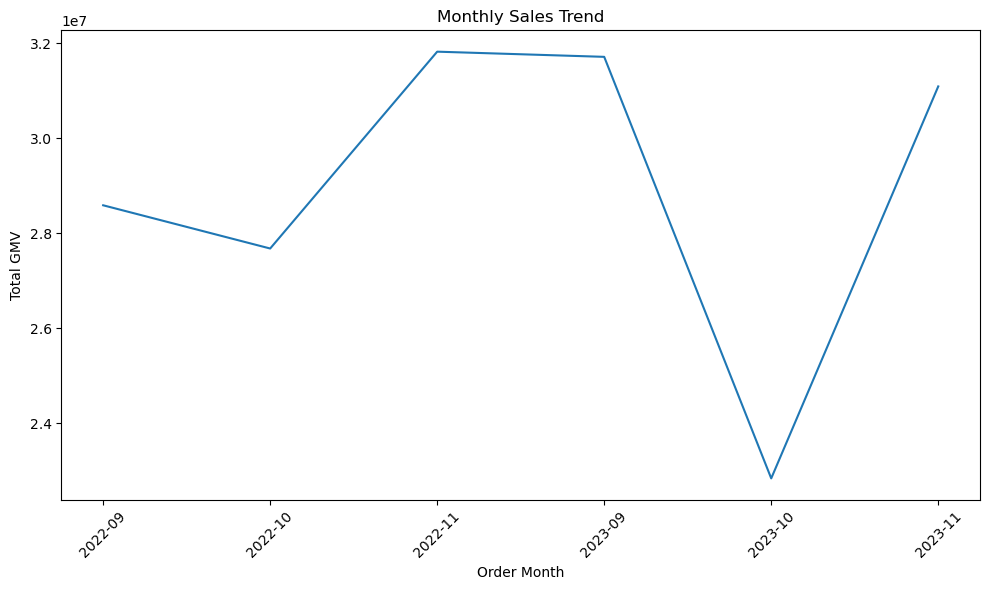

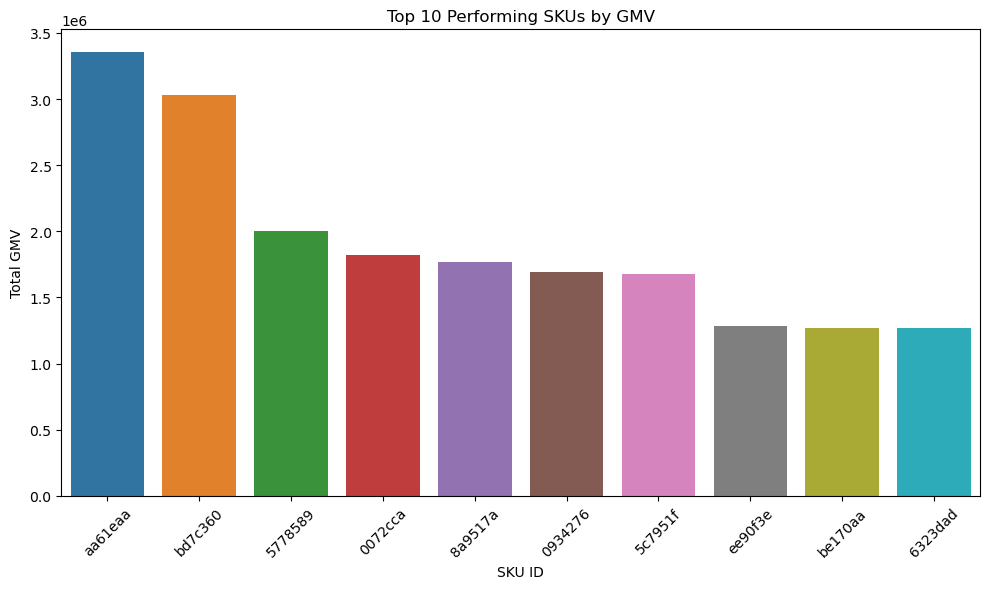

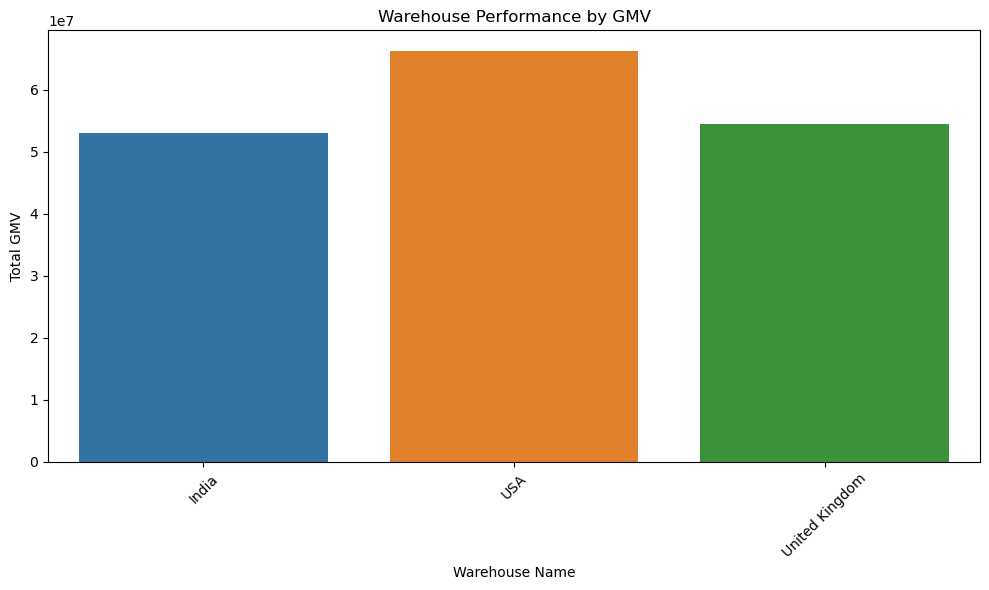

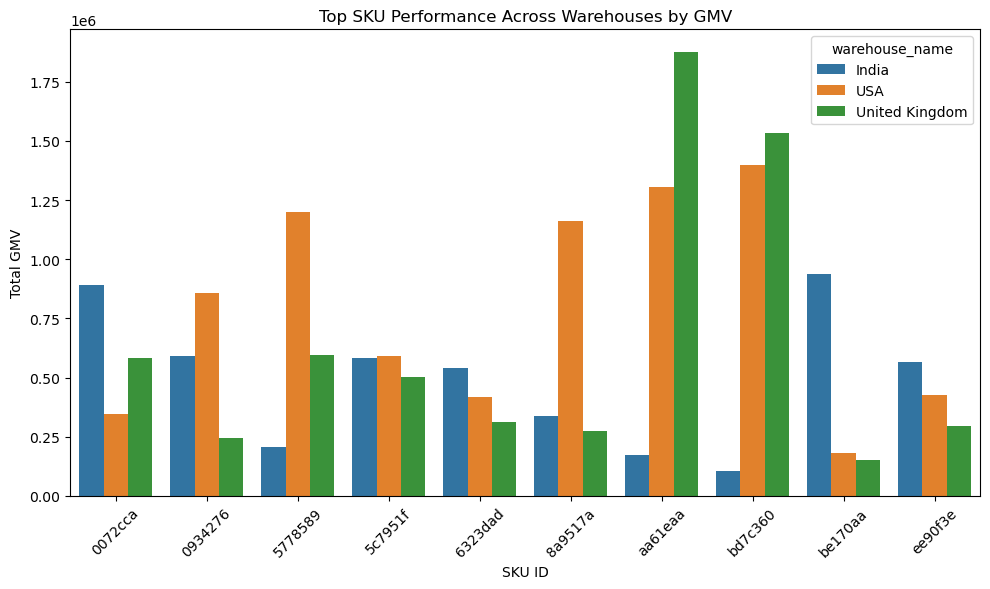

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load and Clean Data
data = pd.read_csv('apnaklub_data_2.csv')

# Convert 'order_date' to datetime format
data['order_date'] = pd.to_datetime(data['order_date'], errors='coerce')

# Drop rows with missing values
data.dropna(inplace=True)

# Step 2: Customer Behavior Analysis
customer_behavior = data.groupby('user_id').agg({
    'order_id': 'nunique',  # Number of unique orders
    'quantity': 'sum',      # Total quantity ordered
    'placed_gmv': 'sum'     # Total value of orders placed
}).reset_index()

customer_behavior.columns = ['user_id', 'total_orders', 'total_quantity', 'total_gmv']

# Segment customers into 'Low', 'Medium', 'High' spenders based on GMV
customer_behavior['segment'] = pd.qcut(customer_behavior['total_gmv'], q=3, labels=['Low', 'Medium', 'High'])

print("Customer Behavior Summary:")
print(customer_behavior.head())

# Step 3: Sales Trends Over Time
data['order_month'] = data['order_date'].dt.to_period('M')

# Group by order month to calculate total GMV and number of unique orders
sales_trends = data.groupby('order_month').agg({
    'placed_gmv': 'sum',
    'order_id': 'nunique'
}).reset_index()

sales_trends.columns = ['order_month', 'total_gmv', 'total_orders']

# Convert order_month to string for plotting
sales_trends['order_month'] = sales_trends['order_month'].astype(str)

print("Sales Trends Summary:")
print(sales_trends.head())

# Step 4: SKU Performance
sku_performance = data.groupby('sku_id').agg({
    'placed_gmv': 'sum',
    'quantity': 'sum',
    'order_id': 'nunique'
}).reset_index()

sku_performance.columns = ['sku_id', 'total_gmv', 'total_quantity', 'total_orders']

# Top and Bottom Performing SKUs
top_skus = sku_performance.sort_values(by='total_gmv', ascending=False).head(10)
bottom_skus = sku_performance.sort_values(by='total_gmv').head(10)

print("Top Performing SKUs:")
print(top_skus)
print("Bottom Performing SKUs:")
print(bottom_skus)

# Step 5: Warehouse Performance
warehouse_performance = data.groupby('warehouse_name').agg({
    'placed_gmv': 'sum',
    'quantity': 'sum',
    'order_id': 'nunique'
}).reset_index()

warehouse_performance.columns = ['warehouse_name', 'total_gmv', 'total_quantity', 'total_orders']

print("Warehouse Performance Summary:")
print(warehouse_performance.head())

# Step 6: Best Selling SKU Across Different Warehouses
sku_warehouse_performance = data.groupby(['warehouse_name', 'sku_id']).agg({
    'placed_gmv': 'sum',
    'quantity': 'sum'
}).reset_index()

# Top SKU per warehouse by GMV
top_sku_per_warehouse = sku_warehouse_performance.loc[sku_warehouse_performance.groupby('warehouse_name')['placed_gmv'].idxmax()]
print("Top SKU per Warehouse:")
print(top_sku_per_warehouse)

# Step 7: High Value Customers Repeat Orders
high_value_customers = customer_behavior[customer_behavior['segment'] == 'High']
repeat_high_value_customers = data[data['user_id'].isin(high_value_customers['user_id'])].groupby('user_id')['order_id'].nunique().reset_index()
print("High Value Customers' Repeat Orders:")
print(repeat_high_value_customers.head())

# Step 8: Low-Performing SKU Lifespan Analysis
low_performing_skus_lifespan = data[data['sku_id'].isin(bottom_skus['sku_id'])].groupby('sku_id')['order_date'].apply(lambda x: (x.max() - x.min()).days)
print("Low-Performing SKUs Lifespan:")
print(low_performing_skus_lifespan)

# Step 9: Profitable Warehouse for Best Selling SKU
sku_profitability_by_warehouse = data.groupby(['sku_id', 'warehouse_name']).agg({
    'placed_gmv': 'sum',
    'quantity': 'sum'
}).reset_index()

# Filter for top selling SKUs
top_sku_profitability = sku_profitability_by_warehouse[sku_profitability_by_warehouse['sku_id'].isin(top_skus['sku_id'])]
print("Top SKU Profitability by Warehouse:")
print(top_sku_profitability)

# Step 10: Visualization

# Sales Trends Over Time
plt.figure(figsize=(10, 6))
sns.lineplot(x='order_month', y='total_gmv', data=sales_trends)
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.xlabel('Order Month')
plt.ylabel('Total GMV')
plt.tight_layout()
plt.show()

# Top 10 Performing SKUs by GMV
plt.figure(figsize=(10, 6))
sns.barplot(x='sku_id', y='total_gmv', data=top_skus)
plt.title('Top 10 Performing SKUs by GMV')
plt.xlabel('SKU ID')
plt.ylabel('Total GMV')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Warehouse Performance by GMV
plt.figure(figsize=(10, 6))
sns.barplot(x='warehouse_name', y='total_gmv', data=warehouse_performance)
plt.title('Warehouse Performance by GMV')
plt.xlabel('Warehouse Name')
plt.ylabel('Total GMV')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top SKU Performance Across Warehouses
plt.figure(figsize=(10, 6))
sns.barplot(x='sku_id', y='placed_gmv', hue='warehouse_name', data=top_sku_profitability)
plt.title('Top SKU Performance Across Warehouses by GMV')
plt.xlabel('SKU ID')
plt.ylabel('Total GMV')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('apnaklub_data_2.csv')

# Example dataset columns: user_id, order_id, order_date, sku_id, warehouse_id, quantity, placed_gmv

# Add a price per unit column (placed_gmv / quantity)
df['price_per_unit'] = df['placed_gmv'] / df['quantity']

# 1. Identify price differences across different warehouses
price_diff_warehouses = df.groupby(['warehouse_name', 'sku_id', 'order_date'])['price_per_unit'].agg(['min', 'max', 'mean', 'std'])
price_diff_warehouses = price_diff_warehouses.reset_index()
price_diff_warehouses['price_diff'] = price_diff_warehouses['max'] - price_diff_warehouses['min']

# Filter for significant price differences
significant_price_diff_warehouses = price_diff_warehouses[price_diff_warehouses['price_diff'] > 0]

# 2. Identify price differences within the same warehouse for the same SKU and date
price_diff_within_warehouse = df.groupby(['warehouse_name', 'sku_id', 'order_date', 'user_id'])['price_per_unit'].agg(['min', 'max'])
price_diff_within_warehouse = price_diff_within_warehouse.reset_index()
price_diff_within_warehouse['price_diff'] = price_diff_within_warehouse['max'] - price_diff_within_warehouse['min']

# Filter for cases where customers pay different prices for the same SKU
significant_price_diff_within = price_diff_within_warehouse[price_diff_within_warehouse['price_diff'] > 0]

# 3. Analyze customer segmentation and order size (e.g., bulk discounts)
customer_order_size = df.groupby('user_id')['quantity'].sum().reset_index()
customer_order_size['segment'] = pd.qcut(customer_order_size['quantity'], 4, labels=['Small', 'Medium', 'Large', 'Very Large'])

# Merge customer segmentation with original dataset
df = df.merge(customer_order_size[['user_id', 'segment']], on='user_id', how='left')

# Analyze pricing by customer segment
price_by_segment = df.groupby('segment')['price_per_unit'].agg(['min', 'max', 'mean', 'std'])

# Output the final insights
print("Significant price differences across warehouses:")
print(significant_price_diff_warehouses)

print("\nSignificant price differences within the same warehouse and same day:")
print(significant_price_diff_within)

print("\nPrice per unit by customer segment:")
print(price_by_segment)

# Exporting results to CSV for further review
significant_price_diff_warehouses.to_csv('warehouse_price_differences.csv', index=False)
significant_price_diff_within.to_csv('within_warehouse_price_differences.csv', index=False)
price_by_segment.to_csv('price_by_customer_segment.csv', index=False)


Significant price differences across warehouses:
       warehouse_name   sku_id  order_date      min      max         mean  \
9               India  0015347  2022-10-15   226.80  3528.96  1877.880000   
12              India  0072cca  2022-09-01   710.00  2115.00  2053.913043   
13              India  0072cca  2022-09-02   710.00  2115.00  1967.105263   
14              India  0072cca  2022-09-03   705.00  2115.00  1921.034483   
15              India  0072cca  2022-09-04   710.00  2115.00  1334.444444   
...               ...      ...         ...      ...      ...          ...   
60074  United Kingdom  ffc1266  2023-09-03  2554.80  6131.52  4343.160000   
60090  United Kingdom  ffc1266  2023-10-16  1040.76  6131.52  2313.450000   
60092  United Kingdom  ffc1266  2023-10-20  1039.28  6122.76  3581.020000   
60093  United Kingdom  ffc1266  2023-10-28  1039.28  6122.76  2733.773333   
60099  United Kingdom  ffc1266  2023-11-20  1033.84  6090.72  2719.466667   

               std  price_

C:\Users\srini\AppData\Local\Temp\ipykernel_24968\207185059.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_segment = df.groupby('segment')['price_per_unit'].agg(['min', 'max', 'mean', 'std'])
